In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cvx_path = 'cvx_with_log.csv'
xom_path = 'xom_with_log.csv'

cvx_data = pd.read_csv(cvx_path)
xom_data = pd.read_csv(xom_path)
cvx_data.head(), xom_data.head()
cvx_data['Date'] = pd.to_datetime(cvx_data['Date'])
xom_data['Date'] = pd.to_datetime(xom_data['Date'])

start_date = '2010-01-01'
end_date = '2012-12-31'

cvx_filtered = cvx_data[(cvx_data['Date'] >= start_date) & (cvx_data['Date'] <= end_date)]
xom_filtered = xom_data[(xom_data['Date'] >= start_date) & (xom_data['Date'] <= end_date)]
merged_data = pd.merge(cvx_filtered[['Date', 'Log_Close']], xom_filtered[['Date', 'Log_Close']], on='Date', suffixes=('_CVX', '_XOM'))
merged_data.head()


,Date,Log_Close_CVX,Log_Close_XOM
0,2010-01-04,4.128521,4.024780
1,2010-01-05,4.135582,4.028703
2,2010-01-06,4.135694,4.037333
3,2010-01-07,4.131913,4.034188
4,2010-01-08,4.133693,4.030162


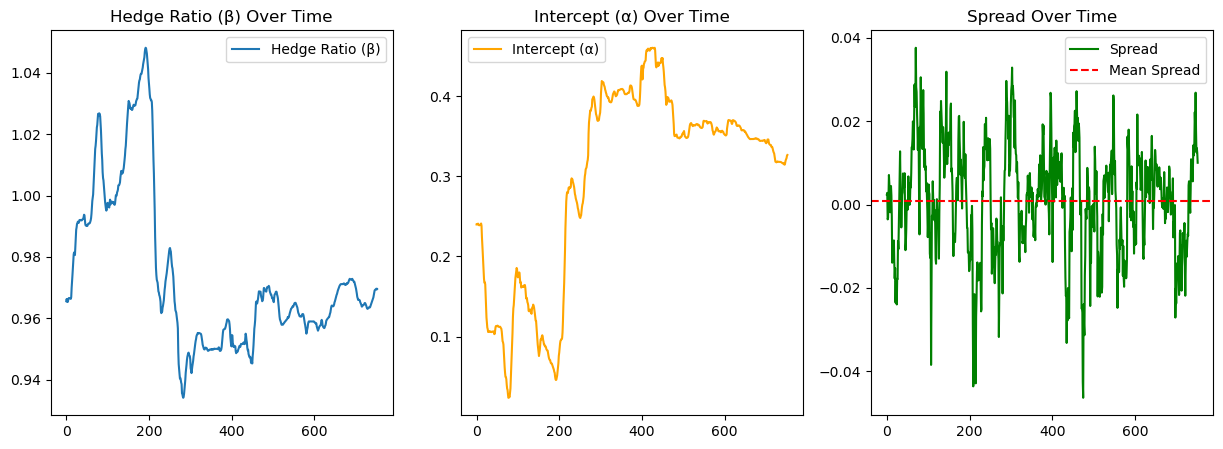

In [ ]:
y = merged_data['Log_Close_CVX'].values  # Dependent variable (Chevron)
x = merged_data['Log_Close_XOM'].values  # Independent variable (ExxonMobil)

# Initialize Kalman Filter parameters
n = len(y)
Q = 1e-5  # Process noise
R = 1e-2  # Measurement noise
beta = np.zeros(n)  # Hedge ratio (β)
alpha = np.zeros(n)  # Intercept (α)
P = np.eye(2)  # Covariance matrix
x_aug = np.vstack([x, np.ones(n)]).T  # Augmented x with ones for intercept

# Initial [beta, alpha]
state = np.array([0, 0]) 


for t in range(n):

    state_pred = state 
    P_pred = P + Q * np.eye(2)

    y_obs = y[t]
    obs_mat = x_aug[t].reshape(1, -1)
    S = obs_mat @ P_pred @ obs_mat.T + R
    K = P_pred @ obs_mat.T @ np.linalg.inv(S)
    state = state_pred + K.flatten() * (y_obs - obs_mat @ state_pred)
    P = P_pred - K @ obs_mat @ P_pred
    beta[t], alpha[t] = state

# Calculate the spread
spread = y - (beta * x + alpha)

# Plot hedge ratio, intercept, and spread
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(beta, label='Hedge Ratio (β)')
plt.title('Hedge Ratio (β) Over Time')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(alpha, label='Intercept (α)', color='orange')
plt.title('Intercept (α) Over Time')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(spread, label='Spread', color='green')
plt.axhline(np.mean(spread), color='red', linestyle='--', label='Mean Spread')
plt.title('Spread Over Time')
plt.legend()

The total return is 0.32705775120469394
The annualized return is 0.0994643806651705
Total Trades: 55.0
Sharpe Ratio: 0.7872


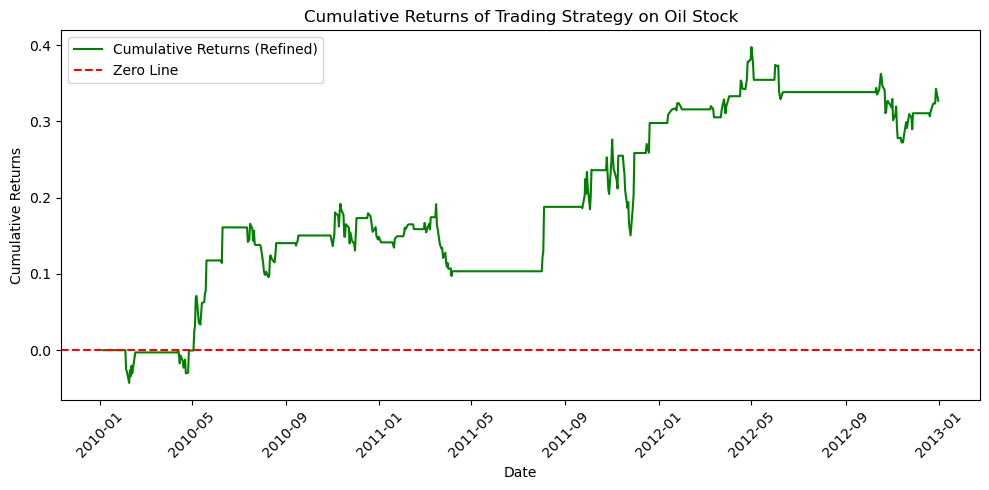

In [ ]:
entry_threshold = 1.5
exit_threshold = 0.5
mean_spread = np.mean(spread)
std_spread = np.std(spread)

long_signal = spread < mean_spread - entry_threshold * std_spread
short_signal = spread > mean_spread + entry_threshold * std_spread
exit_signal = (mean_spread - exit_threshold * std_spread < spread) & \
              (spread < mean_spread + exit_threshold * std_spread)

positions = np.zeros_like(spread)
positions[long_signal] = 1
positions[short_signal] = -1


for i in range(1, len(spread)):
    if exit_signal[i]:
        positions[i] = 0
    elif positions[i] == 0:
        positions[i] = positions[i - 1]


transaction_cost = 0 
trades = np.abs(np.diff(positions))
returns = positions[:-1] * (y[1:] - y[:-1]) - trades * transaction_cost

cumulative_returns = np.cumsum(returns)
sharpe_ratio = np.mean(returns) / np.std(returns) * np.sqrt(252)
total_trades = np.sum(trades)
winning_trades = np.sum(returns > 0)
losing_trades = np.sum(returns <= 0)
win_rate = winning_trades / total_trades if total_trades > 0 else 0

total_return = cumulative_returns[-1]
annualized_return = (1 + total_return) ** (252 / len(returns)) - 1
print(f"The total return is {total_return}") 
print(f"The annualized return is {annualized_return}")
print(f"Total Trades: {total_trades}")
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(merged_data['Date'][1:], cumulative_returns, label='Cumulative Returns (Refined)', color='green')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.title('Cumulative Returns of Trading Strategy on Oil Stock')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

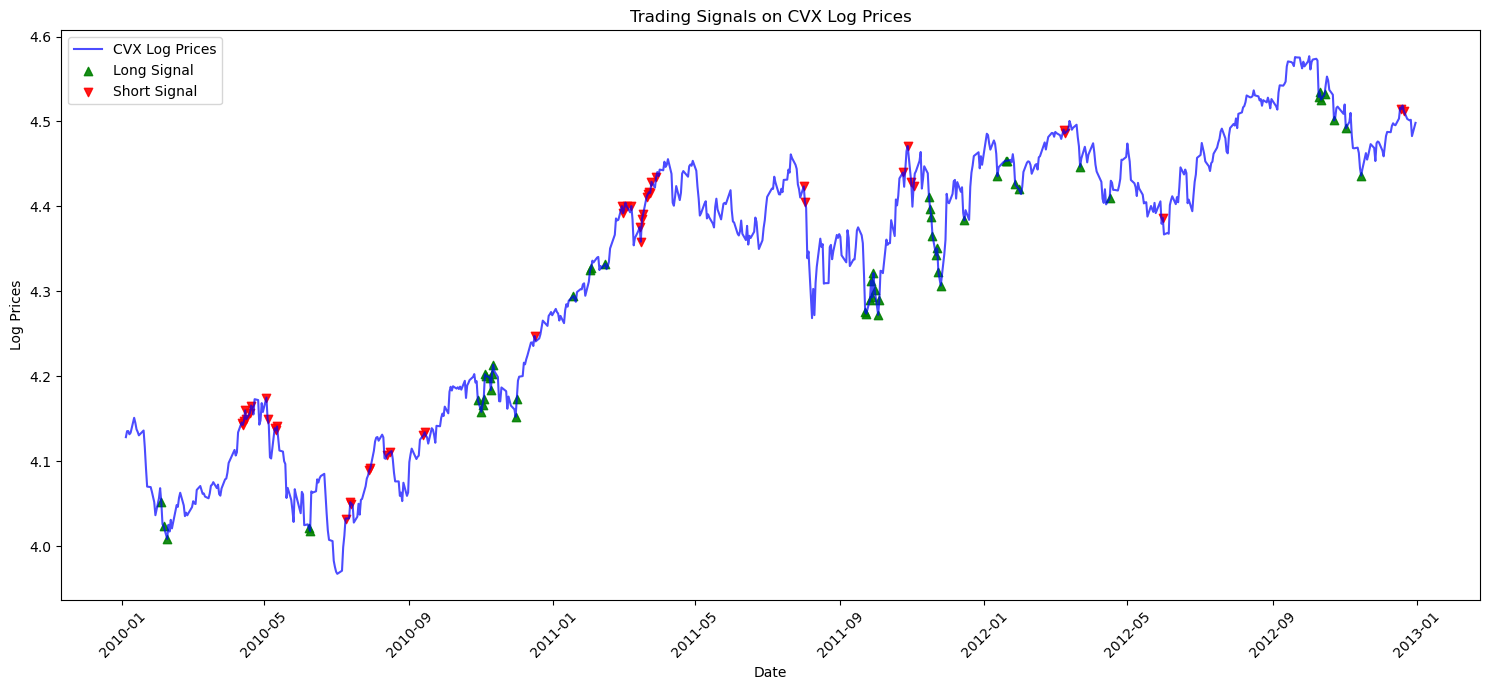

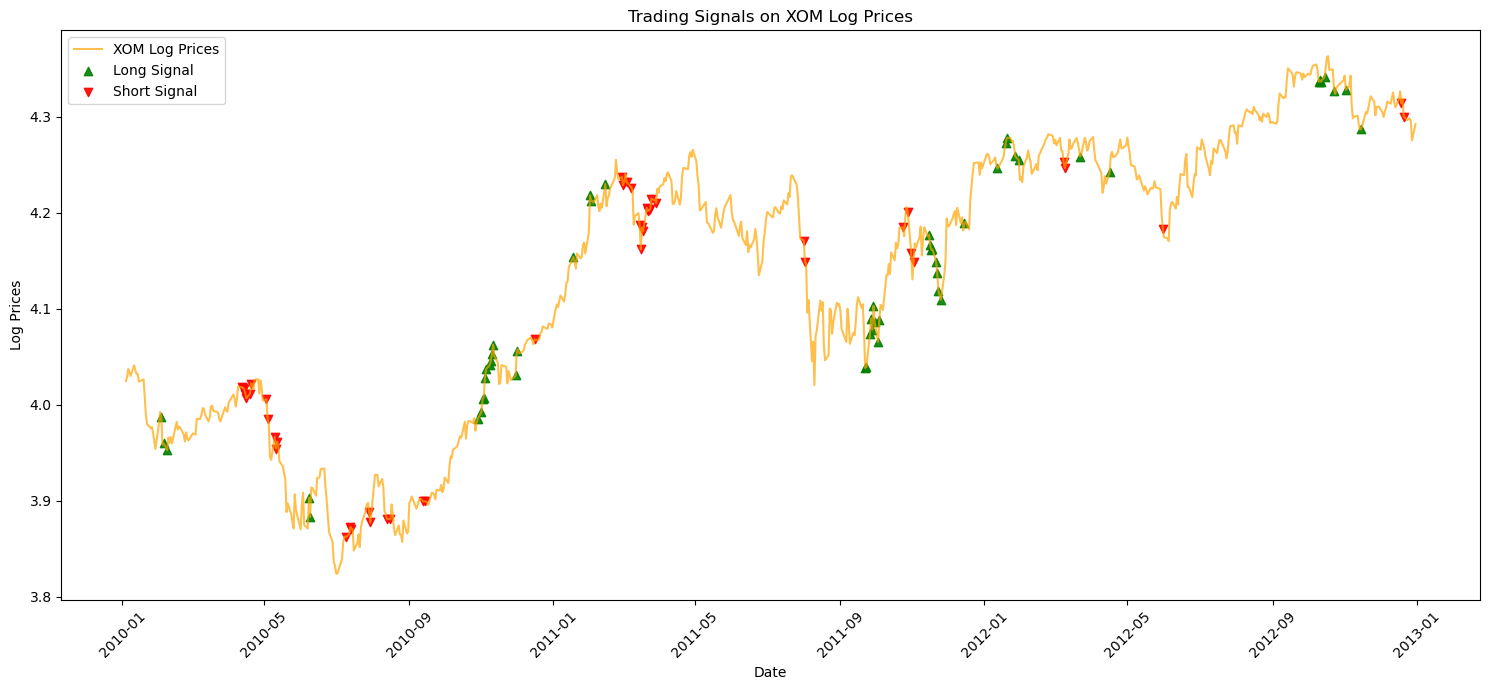

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(merged_data['Date'], y, label='CVX Log Prices', color='blue', alpha=0.7)


plt.scatter(merged_data['Date'][long_signal], y[long_signal], color='green', label='Long Signal', marker='^', alpha=0.9)
plt.scatter(merged_data['Date'][short_signal], y[short_signal], color='red', label='Short Signal', marker='v', alpha=0.9)


plt.title('Trading Signals on CVX Log Prices')
plt.xlabel('Date')
plt.ylabel('Log Prices')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 7))

plt.plot(merged_data['Date'], x, label='XOM Log Prices', color='orange', alpha=0.7)

plt.scatter(merged_data['Date'][long_signal], x[long_signal], color='green', label='Long Signal', marker='^', alpha=0.9)
plt.scatter(merged_data['Date'][short_signal], x[short_signal], color='red', label='Short Signal', marker='v', alpha=0.9)


plt.title('Trading Signals on XOM Log Prices')
plt.xlabel('Date')
plt.ylabel('Log Prices')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



